#Deep Sea Treasure Environment
This notebook implements the Deep Sea Treasure problem, a multi-objective reinforcement learning environment where an agent controls a submarine on a grid to collect treasure. The agent must balance two objectives: minimizing the time taken to reach a treasure and maximizing the treasure value obtained. A Q-learning approach with linear scalarization is used to learn policies and approximate the Pareto front of solutions.

In [1]:
import time
import copy
import random
import numpy as np
from tabulate import tabulate

In [2]:
# 2-d array to create the Deep Sea Treasure grid
game=[]
for i in range(11):
    g=[]
    for j in range(10):
        g.append(' ')   #empty water
    game.append(g)

game[1][0]=1 #reward
for i in range(2,11):
    game[i][0]='**' # blocked cells
game[2][1]=2
for i in range(3,11):
    game[i][1]='**'

game[3][2]=3
for i in range(4,11):
    game[i][2]='**'

game[4][3]=5
for i in range(5,11):
    game[i][3]='**'

game[4][4]=8
for i in range(5,11):
    game[i][4]='**'

game[4][5]=16
for i in range(5,11):
    game[i][5]='**'

game[7][6]=24
for i in range(8,11):
    game[i][6]='**'

game[7][7]=50
for i in range(8,11):
    game[i][7]='**'

game[9][8]=74
for i in range(10,11):
    game[i][8]='**'

game[10][9]=124
game[0][0]='@'


In [3]:
print (tabulate(game, tablefmt="fancy_grid"))

╒════╤════╤════╤════╤════╤════╤════╤════╤════╤═════╕
│ @  │    │    │    │    │    │    │    │    │     │
├────┼────┼────┼────┼────┼────┼────┼────┼────┼─────┤
│ 1  │    │    │    │    │    │    │    │    │     │
├────┼────┼────┼────┼────┼────┼────┼────┼────┼─────┤
│ ** │ 2  │    │    │    │    │    │    │    │     │
├────┼────┼────┼────┼────┼────┼────┼────┼────┼─────┤
│ ** │ ** │ 3  │    │    │    │    │    │    │     │
├────┼────┼────┼────┼────┼────┼────┼────┼────┼─────┤
│ ** │ ** │ ** │ 5  │ 8  │ 16 │    │    │    │     │
├────┼────┼────┼────┼────┼────┼────┼────┼────┼─────┤
│ ** │ ** │ ** │ ** │ ** │ ** │    │    │    │     │
├────┼────┼────┼────┼────┼────┼────┼────┼────┼─────┤
│ ** │ ** │ ** │ ** │ ** │ ** │    │    │    │     │
├────┼────┼────┼────┼────┼────┼────┼────┼────┼─────┤
│ ** │ ** │ ** │ ** │ ** │ ** │ 24 │ 50 │    │     │
├────┼────┼────┼────┼────┼────┼────┼────┼────┼─────┤
│ ** │ ** │ ** │ ** │ ** │ ** │ ** │ ** │    │     │
├────┼────┼────┼────┼────┼────┼────┼────┼────┼

In [5]:
game1=copy.deepcopy(game) # Save the original board so we can reset later because after each episode, the environment must go back to the initial state.

# reward map for treasure values
r = np.array([[-1, -1, -1, -1, -1, -1, -1, -1, -1, -1],
              [1, -1, -1, -1, -1, -1, -1, -1, -1, -1],
              [0, 2, -1, -1, -1, -1, -1, -1, -1, -1],
              [0, 0, 3, -1, -1, -1, -1, -1, -1, -1],
              [0, 0, 0, 5, 8, 16, -1, -1, -1, -1],
              [0, 0, 0, 0, 0, 0, -1, -1, -1, -1],
              [0, 0, 0, 0, 0, 0, -1, -1, -1, -1],
              [0, 0, 0, 0, 0, 0, 24, 50, -1, -1],
              [0, 0, 0, 0, 0, 0, 0, 0, -1, -1],
              [0, 0, 0, 0, 0, 0, 0, 0, 74, -1],
              [0, 0, 0, 0, 0, 0, 0, 0, 0, 124]])

In [9]:
#creating states
k=0
states=[]
for i in range(11):
    for j in range(10):
        if r[i][j]!=0:
            states.append([k,i,j])
            k=k+1
print("Number of states:", len(states))

Number of states: 61


In [11]:
#Defining actions

def goUp():
    global states
    negativeReward=0
    positiveReward=0
    for i in range(11):
        if '@' in game[i]:
            j=game[i].index('@')
            if i!=0 and game[i-1][j]==' ':
                game[i][j]=' '
                game[i-1][j]='@'
                negativeReward=1
                break
            elif i!=0 and type(game[i-1][j])==int:
                positiveReward=game[i-1][j]
                game[i][j]=' '
                game[i-1][j]='@'
                break
    m=0
    n=0
    for i in range(11):
        if '@' in game[i]:
            m=i
            n=game[i].index('@')
    h=0
    for each in states:
        if each[1]==m and each[2]==n:
            h=each[0]
    if negativeReward>0:
        return (h,negativeReward,0)
    if positiveReward>0:
        return (h,1,positiveReward)
    return (h,1,0) #(new_state, time_cost, treasure_reward)

def goDown():
    global states
    negativeReward=0
    positiveReward=0
    for i in range(11):
        if '@' in game[i]:
            j=game[i].index('@')
            if i!=10 and game[i+1][j]==' ':
                game[i][j]=' '
                game[i+1][j]='@'
                negativeReward=1
                break
            elif i!=10 and type(game[i+1][j])==int:
                positiveReward=game[i+1][j]
                game[i][j]=' '
                game[i+1][j]='@'
                break

    m=0
    n=0
    for i in range(11):
        if '@' in game[i]:
            m=i
            n=game[i].index('@')
    h=0
    for each in states:
        if each[1]==m and each[2]==n:
            h=each[0]
    if negativeReward>0:
        return (h,negativeReward,0)
    if positiveReward>0:
        return (h,1,positiveReward)
    return (h,1,0)

def goLeft():
    global states
    negativeReward=0
    positiveReward=0
    for i in range(11):
        if '@' in game[i]:
            j=game[i].index('@')
            if j!=0 and game[i][j-1]==' ':
                game[i][j]=' '
                game[i][j-1]='@'
                negativeReward=1
                break
            elif j!=0 and type(game[i][j-1])==int:
                positiveReward=game[i][j-1]
                game[i][j]=' '
                game[i][j-1]='@'
                break

    m=0
    n=0
    for i in range(11):
        if '@' in game[i]:
            m=i
            n=game[i].index('@')
    h=0
    for each in states:
        if each[1]==m and each[2]==n:
            h=each[0]
    if negativeReward>0:
        return (h,negativeReward,0)
    if positiveReward>0:
        return (h,1,positiveReward)
    return (h,1,0)


def goRight():
    global states
    negativeReward=0
    positiveReward=0
    for i in range(11):
        if '@' in game[i]:
            j=game[i].index('@')
            if j!=9 and game[i][j+1]==' ':
                game[i][j]=' '
                game[i][j+1]='@'
                negativeReward=1
                break
            elif j!=9 and type(game[i][j+1])==int:
                positiveReward=game[i][j+1]
                game[i][j]=' '
                game[i][j+1]='@'
                break
    m=0
    n=0
    for i in range(11):
        if '@' in game[i]:
            m=i
            n=game[i].index('@')
    h=0
    for each in states:
        if each[1]==m and each[2]==n:
            h=each[0]
    if negativeReward>0:
        return (h,negativeReward,0)
    if positiveReward>0:
        return (h,1,positiveReward)
    return (h,1,0)

In [15]:
#resets the board to the original state before each episode.
def reset():
    global game
    game=copy.deepcopy(game1)


In [16]:

paretoList=[]

def qlearning(timeW,treasureW):
    #Initialize table with all zeros
    Q1 = np.zeros([61,4]) #Q1 for time
    Q2 = np.zeros([61,4]) #Q2 for treasure
    Q = np.zeros([61,4]) #Q for combined:Q=wt​Q1​+wr​Q2​

    # Set learning parameters
    lr = 0.9
    y = 0.95
    num_episodes = 15000
    paretoList=[]

    for i in range(num_episodes):
        #Reset environment and get first new observation
        reset()
        s = 0
        rAll = 0
        totalTime=0
        treasure=0
        j=0

        #The Q-Table learning algorithm
        while totalTime<500:  #time limit
            j=j+1

            #Choose an action by greedily (with noise) picking from Q table
            a = np.argmax(Q[s,:] + np.random.randn(1,4)*(20))

            #Get new state and reward from environment
            if a==0:
                s1,time,treasure = goRight()
            if a==1:
                s1,time,treasure = goLeft()

            if a==2:
                s1,time,treasure = goUp()

            if a==3:
                s1,time,treasure = goDown()

            totalTime=totalTime+time

            #Update Q-Table with new knowledge
            Q1[s,a] = Q1[s,a] + lr*((-time) + y*np.max(Q1[s1,:]) - Q1[s,a])
            Q2[s,a] = Q2[s,a] + lr*(treasure + y*np.max(Q2[s1,:]) - Q2[s,a])
            Q[s,a]= timeW*Q1[s,a] + treasureW*Q2[s,a]
            s = s1
            if treasure>=1:
                break
        paretoList.append([-totalTime,treasure])

    print('Pareto Front')

    paretoFront=[]
    for each in paretoList:
        paretoFront.append(each)
        for e in paretoList:
            if (e[1]>each[1] and e[0]>=each[0]) or (e[1]>=each[1] and e[0]>each[0]) :
                paretoFront.remove(each)
                paretoList.remove(each)
                break

    paretoFront1=[]
    for each in paretoFront:
        if each not in paretoFront1:
            paretoFront1.append(each)

    print('The solutions in pareto front has rewards related to time and treasure respectively.')
    print(paretoFront1)
    return paretoFront1

In [20]:
#User intereaction for getting weights from user.

print('For scalarization function, 2 weights are needed, one for minimizing time consumption as an objective and another for treasure as an objective:')
timeW=float(input('Enter weight in the range of 0 to 1 as an emphasis you want to put on time minimization objective:'))
treasureW=float(input('Enter weight in the range of 0 to 1 as an emphasis you want to put on treasure objective:'))

For scalarization function, 2 weights are needed, one for minimizing time consumption as an objective and another for treasure as an objective:
Enter weight in the range of 0 to 1 as an emphasis you want to put on time minimization objective:0.6
Enter weight in the range of 0 to 1 as an emphasis you want to put on treasure objective:0.4


In [21]:

result1=qlearning(timeW,treasureW)
r1_goal0=[]
r1_goal1=[]
for each in result1:
    r1_goal0.append(each[0])  # time rewards
    r1_goal1.append(each[1])  # treasure rewards


Pareto Front
The solutions in pareto front has rewards related to time and treasure respectively.
[[-1, 1], [-3, 2], [-7, 5], [-5, 3], [-16, 50], [-23, 124], [-8, 8]]


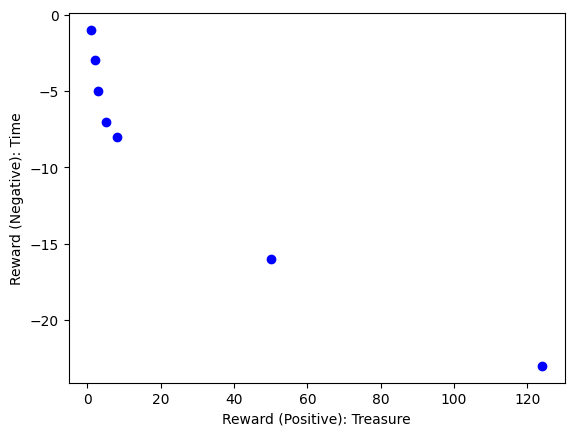

In [23]:
#plotting Pareto front
import matplotlib.pyplot as plt
plt.xlabel('Reward (Positive): Treasure')
plt.ylabel('Reward (Negative): Time')
plt.scatter(r1_goal1,r1_goal0,color='blue')
plt.show()

## Summary

The obtained Pareto front shows the trade-off between **minimizing time** and **maximizing treasure value** in the Deep Sea Treasure environment. Each point represents a non-dominated solution, meaning that improving one objective would worsen the other. The results indicate that smaller treasures can be collected quickly, while larger treasures require longer paths. This illustrates the multi-objective nature of the problem and the need to balance speed against reward.